# Fleet Reliability Data Engineering Platform
# Objective:
Build KPI tables and business insights for fleet reliability analysis.

This notebook analyzes fleet reliability metrics from engineered vehicle features.

## KPIs Covered
- Repair rate by model
- Component failure analysis
- Warranty cost metrics
- Downtime trends
- Risk scoring
- Regional performance
- Battery health vs failures
- Warning vs failure relationships

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [3]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [4]:
# Define Paths
feature_path = "data/featured"
output_path = "outputs/charts"

os.makedirs(output_path, exist_ok=True)

In [5]:
from google.colab import files
uploaded = files.upload()

Saving vehicle_features.csv to vehicle_features.csv


In [7]:
# Load Feature Table
vehicle_features = pd.read_csv("vehicle_features.csv")

print("Shape:", vehicle_features.shape)
vehicle_features.head()

Shape: (50000, 117)


,vehicle_id,vin,model,model_year,battery_type,delivery_date,region,mileage,fleet_type,vehicle_age_days,vehicle_age_months,vehicle_age_years,mileage_band,total_services,repairs_last_30d,repairs_last_90d,repairs_last_180d,avg_repair_cost,max_repair_cost,total_repair_cost,avg_downtime_days,max_downtime_days,total_downtime_days,repeat_issue_count,last_service_date,days_since_last_service,repeat_repair_ratio,critical_severity_count,high_severity_count,low_severity_count,medium_severity_count,battery_issue_count,brake_issue_count,electrical_issue_count,hvac_issue_count,motor_issue_count,software_issue_count,suspension_issue_count,telemetry_records,avg_battery_health,min_battery_health,avg_motor_temp,max_motor_temp,avg_brake_temp,max_brake_temp,avg_tire_pressure_alerts,total_tire_pressure_alerts,avg_warning_count,max_warning_count,total_warning_count,recent_telemetry_30d,recent_telemetry_90d,last_telemetry_date,days_since_last_telemetry,latest_telemetry_date,latest_battery_health,latest_motor_temp,latest_brake_temp,latest_tire_pressure_alerts,latest_software_version,latest_warning_count,total_claims,claims_last_90d,claims_last_180d,total_claim_amount,avg_claim_amount,max_claim_amount,last_claim_date,days_since_last_claim,approved_claim_count,pending_claim_count,rejected_claim_count,total_failures,failures_last_90d,failures_last_180d,replaced_count,last_failure_date,days_since_last_failure,electrical_fault,mechanical_failure,software_error,thermal_issue,wear,12v_battery,abs_module,ac_compressor,autopilot_computer,battery_pack,bms,brake_pads,brake_rotor,cabin_heater,charging_port,control_arm,cooling_fan,drive_unit,firmware,infotainment_module,inverter,motor_controller,sensor_module,shock_absorber,suspension_link,wiring_harness,claims_per_service,failures_per_service,avg_cost_per_downtime_day,warning_to_failure_ratio,service_per_year,claim_per_year,failure_per_year,high_repair_frequency_flag,high_warning_flag,low_battery_health_flag,high_claim_cost_flag,repeat_repair_flag,fleet_risk_score
0,1,5YJ00000000000001,Model 3,2025,NCA,2020-04-11,Asia Pacific,1269,Retail,2150,71.7,5.89,Low,9.0,0.0,1.0,1.0,1641.293333,5206.91,14771.64,2.633333,5.4,23.7,1.0,2025-12-14,77.0,0.111111,0.0,3.0,4.0,2.0,1.0,0.0,1.0,1.0,1.0,4.0,1.0,8.0,97.595000,95.70,70.687500,85.57,57.071250,69.930000,0.250000,2.0,1.500000,3.0,12.0,1.0,2.0,2026-02-02,27.0,2026-02-02,97.86,70.95,47.300000,0.0,2024.38.1,1.0,3.0,0.0,1.0,3621.34,1207.113333,1553.92,2025-10-14,138.0,0.0,3.0,0.0,3.0,0.0,0.0,2.0,2024-06-27,612.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,623.275949,4.000000,1.528014,0.509338,0.509338,0,0,0,0,0,0
1,2,5YJ00000000000002,Model Y,2025,NCM,2019-01-22,North America,3505,Retail,2595,86.5,7.11,Low,7.0,0.0,1.0,2.0,1715.110000,3449.08,12005.77,2.457143,4.0,17.2,1.0,2026-01-01,59.0,0.142857,0.0,3.0,3.0,1.0,0.0,0.0,1.0,1.0,2.0,0.0,3.0,15.0,97.442667,92.61,70.212667,96.13,60.308000,70.240000,0.466667,7.0,1.600000,4.0,24.0,1.0,6.0,2026-02-10,19.0,2026-02-10,98.84,76.21,54.230000,1.0,2024.38.1,2.0,3.0,0.0,0.0,4276.06,1425.353333,2354.44,2024-04-13,687.0,2.0,0.0,1.0,3.0,0.0,0.0,2.0,2024-07-29,580.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.428571,0.428571,698.009884,8.000000,0.984529,0.421941,0.421941,0,0,0,0,0,0
2,3,5YJ00000000000003,Model 3,2023,LFP,2024-08-30,Europe,58323,Retail,548,18.3,1.50,High,4.0,0.0,0.0,2.0,1585.157500,2295.66,6340.63,4.000000,6.4,16.0,1.0,2025-11-20,101.0,0.250000,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,6.0,92.931667,89.57,66.558333,75.42,59.407898,72.692421,0.333333,2.0,1.833333,3.0,11.0,2.0,3.0,2026-02-22,7.0,2026-02-22,97.26,69.11,69.177330,1.0,2024.38.1,3.0,1.0,0.0,0.0,676.66,676.660000,676.66,2023-05-31,1005.0,0.0,1.0,0.0,7.0,0.0,0.0,7.0,2025-02-18,376.0,1.0,0.0,3.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.250000,1.750000,396.289375,1.571429,2.6666

In [8]:
# Basic Dataset Overview
print("Total Vehicles:", vehicle_features.shape[0])
print("Total Services:", int(vehicle_features["total_services"].sum()))
print("Total Failures:", int(vehicle_features["total_failures"].sum()))
print("Total Claims:", int(vehicle_features["total_claims"].sum()))

Total Vehicles: 50000
Total Services: 300000
Total Failures: 120000
Total Claims: 100000


In [9]:
# Repair Rate by Model
repair_by_model = vehicle_features.groupby("model").agg(
    total_vehicles=("vehicle_id", "count"),
    total_services=("total_services", "sum")
).reset_index()

repair_by_model["repair_rate_per_vehicle"] = (
    repair_by_model["total_services"] / repair_by_model["total_vehicles"]
)

repair_by_model.sort_values("repair_rate_per_vehicle", ascending=False)

,model,total_vehicles,total_services,repair_rate_per_vehicle
2,Model S,6090,36832.0,6.047947
1,Model 3,16909,101439.0,5.999113
4,Model Y,17100,102500.0,5.994152
0,Cybertruck,4970,29734.0,5.982696
3,Model X,4931,29495.0,5.981545


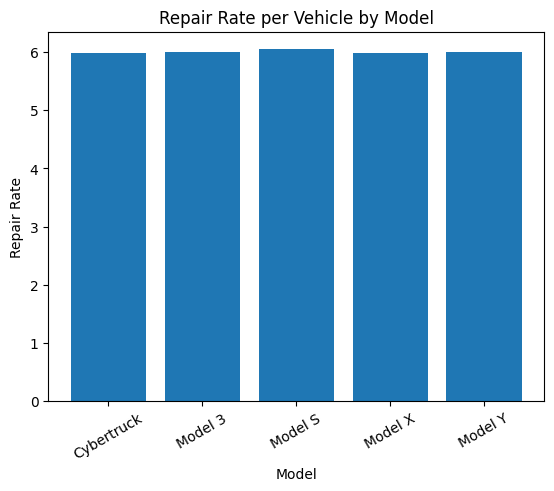

In [10]:
# Plot

plt.figure()
plt.bar(repair_by_model["model"], repair_by_model["repair_rate_per_vehicle"])
plt.title("Repair Rate per Vehicle by Model")
plt.xlabel("Model")
plt.ylabel("Repair Rate")
plt.xticks(rotation=30)
plt.show()

In [11]:
# Top Failing Components

component_cols = [col for col in vehicle_features.columns if "_count" in col and "issue" in col]

component_failure = vehicle_features[component_cols].sum().sort_values(ascending=False).head(10)

component_failure

,0
software_issue_count,53964.0
battery_issue_count,53790.0
brake_issue_count,47883.0
repeat_issue_count,45493.0
motor_issue_count,42029.0
suspension_issue_count,36315.0
electrical_issue_count,35937.0
hvac_issue_count,30082.0


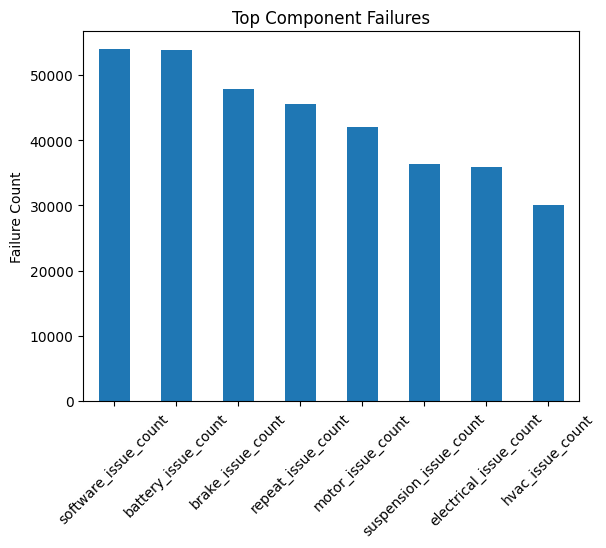

In [12]:
# Plot

plt.figure()
component_failure.plot(kind="bar")
plt.title("Top Component Failures")
plt.ylabel("Failure Count")
plt.xticks(rotation=45)
plt.show()

In [13]:
# Warranty Cost Analysis

warranty_kpi = vehicle_features.groupby("model").agg(
    total_claim_amount=("total_claim_amount", "sum"),
    avg_claim_amount=("avg_claim_amount", "mean")
).reset_index()

warranty_kpi

,model,total_claim_amount,avg_claim_amount
0,Cybertruck,25000047.94,2189.372110
1,Model 3,86901369.37,2222.402901
2,Model S,30872917.97,2223.763708
3,Model X,25193396.61,2174.521117
4,Model Y,87802810.86,2224.385426


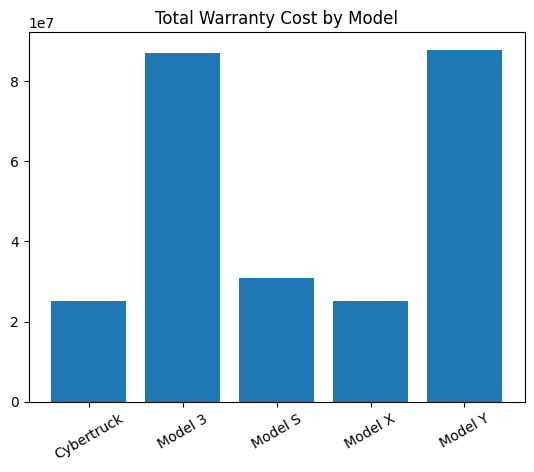

In [14]:
# Plot

plt.figure()
plt.bar(warranty_kpi["model"], warranty_kpi["total_claim_amount"])
plt.title("Total Warranty Cost by Model")
plt.xticks(rotation=30)
plt.show()

In [15]:
# Downtime Analysis

downtime_kpi = vehicle_features.groupby("model").agg(
    avg_downtime=("avg_downtime_days", "mean"),
    total_downtime=("total_downtime_days", "sum")
).reset_index()

downtime_kpi

,model,avg_downtime,total_downtime
0,Cybertruck,3.607235,107301.2
1,Model 3,3.602898,366181.9
2,Model S,3.593110,132816.1
3,Model X,3.590146,106034.3
4,Model Y,3.597348,369145.2


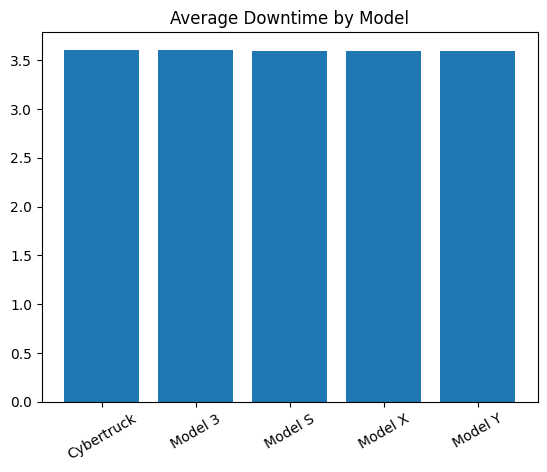

In [16]:
# Plot

plt.figure()
plt.bar(downtime_kpi["model"], downtime_kpi["avg_downtime"])
plt.title("Average Downtime by Model")
plt.xticks(rotation=30)
plt.show()

In [17]:
# High Risk Vehicles

high_risk = vehicle_features[vehicle_features["fleet_risk_score"] >= 3]

print("High Risk Vehicles:", high_risk.shape[0])

High Risk Vehicles: 387


In [18]:
# Risk Distribution

risk_dist = vehicle_features["fleet_risk_score"].value_counts().sort_index()

risk_dist

,count
fleet_risk_score,
0,32980
1,13384
2,3249
3,369
4,18


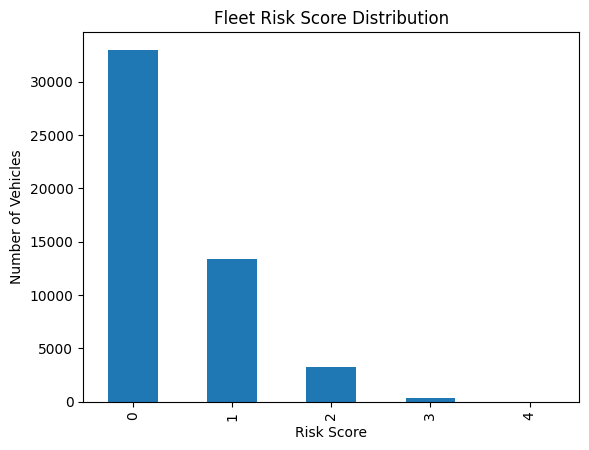

In [20]:
# Plot
plt.figure()
risk_dist.plot(kind="bar")
plt.title("Fleet Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Vehicles")
plt.show()

In [21]:
# Region Wise Reliability

region_kpi = vehicle_features.groupby("region").agg(
    avg_repair=("total_services", "mean"),
    avg_failure=("total_failures", "mean"),
    avg_claim=("total_claims", "mean")
).reset_index()

region_kpi

,region,avg_repair,avg_failure,avg_claim
0,Asia Pacific,6.022978,2.398078,2.011369
1,Europe,6.004845,2.387365,1.986012
2,Middle East,5.973894,2.434610,1.991049
3,North America,5.989579,2.401020,2.002084


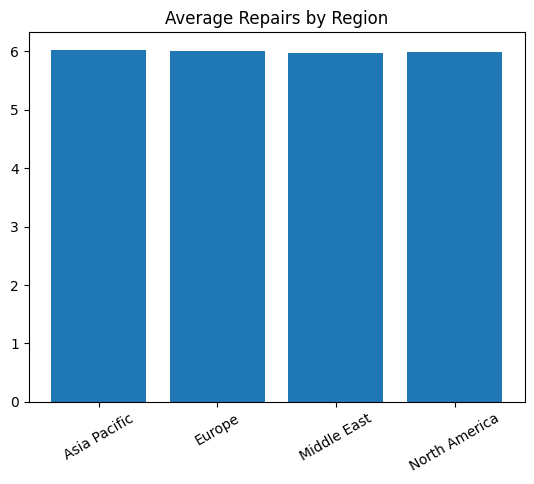

In [22]:
# Plot

plt.figure()
plt.bar(region_kpi["region"], region_kpi["avg_repair"])
plt.title("Average Repairs by Region")
plt.xticks(rotation=30)
plt.show()

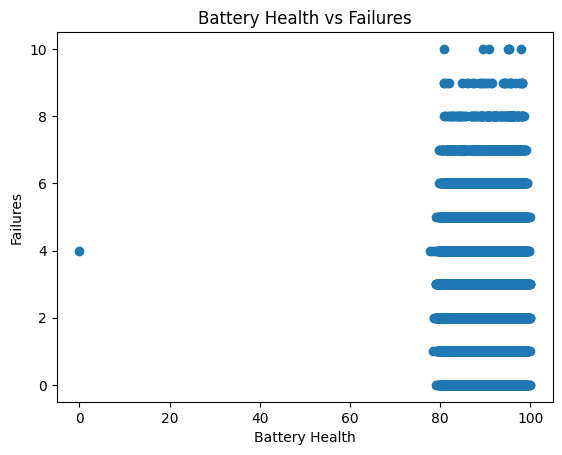

In [23]:
# Battery Health vs Fitness

plt.figure()
plt.scatter(vehicle_features["avg_battery_health"], vehicle_features["total_failures"])
plt.xlabel("Battery Health")
plt.ylabel("Failures")
plt.title("Battery Health vs Failures")
plt.show()

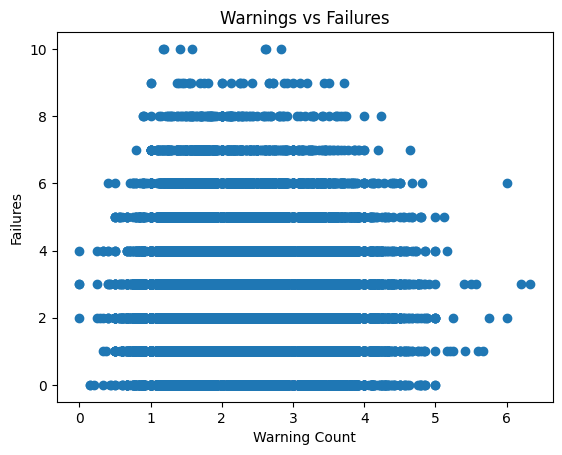

In [24]:
# Warning vs. Failure Relationship

plt.figure()
plt.scatter(vehicle_features["avg_warning_count"], vehicle_features["total_failures"])
plt.xlabel("Warning Count")
plt.ylabel("Failures")
plt.title("Warnings vs Failures")
plt.show()

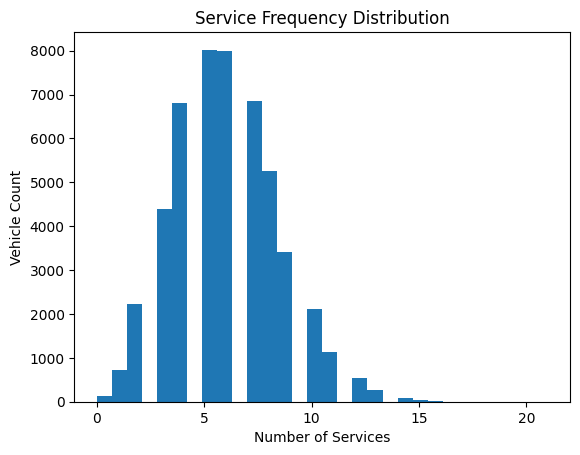

In [25]:
# Service Frequency Distribution

plt.figure()
plt.hist(vehicle_features["total_services"], bins=30)
plt.title("Service Frequency Distribution")
plt.xlabel("Number of Services")
plt.ylabel("Vehicle Count")
plt.show()

In [26]:
# Top 10 High Rish Vehicles

top_risk = vehicle_features.sort_values("fleet_risk_score", ascending=False).head(10)

top_risk[[
    "vehicle_id",
    "model",
    "region",
    "fleet_risk_score",
    "total_services",
    "total_failures",
    "total_claim_amount"
]]

,vehicle_id,model,region,fleet_risk_score,total_services,total_failures,total_claim_amount
28162,28163,Model Y,Asia Pacific,4,4.0,2.0,13877.98
3141,3142,Cybertruck,Asia Pacific,4,9.0,1.0,13388.55
32221,32222,Cybertruck,North America,4,6.0,2.0,12790.66
27573,27574,Model Y,North America,4,6.0,4.0,12418.62
45361,45362,Model 3,North America,4,3.0,4.0,15116.39
18934,18935,Model X,North America,4,4.0,1.0,12113.46
45632,45633,Model X,Middle East,4,3.0,2.0,13288.71
36352,36353,Model 3,North America,4,1.0,4.0,13686.01
31387,31388,Model Y,North America,4,9.0,1.0,15823.72
13463,13464,Model X,Asia Pacific,4,3.0,1.0,15926.17


In [27]:
# Save KPI tables

repair_by_model.to_csv(f"{output_path}/repair_by_model.csv", index=False)
warranty_kpi.to_csv(f"{output_path}/warranty_kpi.csv", index=False)
downtime_kpi.to_csv(f"{output_path}/downtime_kpi.csv", index=False)
region_kpi.to_csv(f"{output_path}/region_kpi.csv", index=False)

print("KPI tables saved.")

KPI tables saved.


# Output

KPI tables and visual insights used for dashboard and business decision-making.